In [ ]:
# ============================================================
# Traffic Flow Prediction with MLP — Foundations of ML Project
# Task: predict next 5-min traffic at a junction from the past 1 hour.
# Dataset: Huawei Munich 6-cross data (5-min readings).
# Models: Linear Regression, MLP (SGD), MLP (mini-batch).
# Training: gradient descent  w <- w - lr*gradient, lr=0.01, 20 epochs.
# No compression techniques used.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, explained_variance_score)

import torch
import torch.nn as nn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
sns.set_style("whitegrid")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Libraries loaded. Device:", device)

Libraries loaded. Device: cpu


In [ ]:
from google.colab import files
uploaded = files.upload()
FILENAME = list(uploaded.keys())[0]
print("Uploaded:", FILENAME)

Saving traffic-prediction-dataset.csv to traffic-prediction-dataset.csv
Uploaded: traffic-prediction-dataset.csv


In [ ]:
df = pd.read_csv(FILENAME)
df.columns = [c.strip() for c in df.columns]
print("Shape:", df.shape, "| Columns:", list(df.columns))
df.head()

Shape: (16128, 6) | Columns: ['Cross 1', 'Cross 2', 'Cross 3', 'Cross 4', 'Cross 5', 'Cross 6']


,Cross 1,Cross 2,Cross 3,Cross 4,Cross 5,Cross 6
0,105.0,48.0,30,62.0,31,110.0
1,97.0,41.0,32,55.0,42,103.0
2,76.0,47.0,44,58.0,40,100.0
3,98.0,40.0,39,59.0,43,104.0
4,87.0,41.0,47,49.0,35,112.0


In [ ]:
print("=== DATA TYPES ===");          print(df.dtypes, "\n")
print("=== MISSING VALUES ===");      print(df.isna().sum(), "\n")
print("=== DUPLICATE ROWS:", df.duplicated().sum(), "\n")
print("=== SUMMARY STATISTICS ===");  display(df.describe().round(1))
print("\nExpected rows (288*56):", 288 * 56, "| actual:", len(df))
print("\n=== ZERO COUNTS PER CROSS ===")
print((df == 0).sum())

=== DATA TYPES ===
Cross 1    float64
Cross 2    float64
Cross 3      int64
Cross 4    float64
Cross 5      int64
Cross 6    float64
dtype: object 

=== MISSING VALUES ===
Cross 1    0
Cross 2    0
Cross 3    0
Cross 4    0
Cross 5    0
Cross 6    0
dtype: int64 

=== DUPLICATE ROWS: 2929 

=== SUMMARY STATISTICS ===


,Cross 1,Cross 2,Cross 3,Cross 4,Cross 5,Cross 6
count,16128.0,16128.0,16128.0,16128.0,16128.0,16128.0
mean,95.8,45.9,41.5,67.7,36.2,76.2
std,87.6,50.9,41.8,68.5,37.4,68.1
min,0.0,0.0,0.0,0.0,0.0,0.0
25%,8.0,2.0,1.0,0.0,1.0,5.0
50%,88.0,29.0,32.0,45.0,28.0,66.0
75%,169.0,77.0,73.0,124.0,60.0,139.0
max,352.5,302.0,218.0,312.0,193.0,253.0



Expected rows (288*56): 16128 | actual: 16128

=== ZERO COUNTS PER CROSS ===
Cross 1    3615
Cross 2    3473
Cross 3    3952
Cross 4    4060
Cross 5    3947
Cross 6    3986
dtype: int64


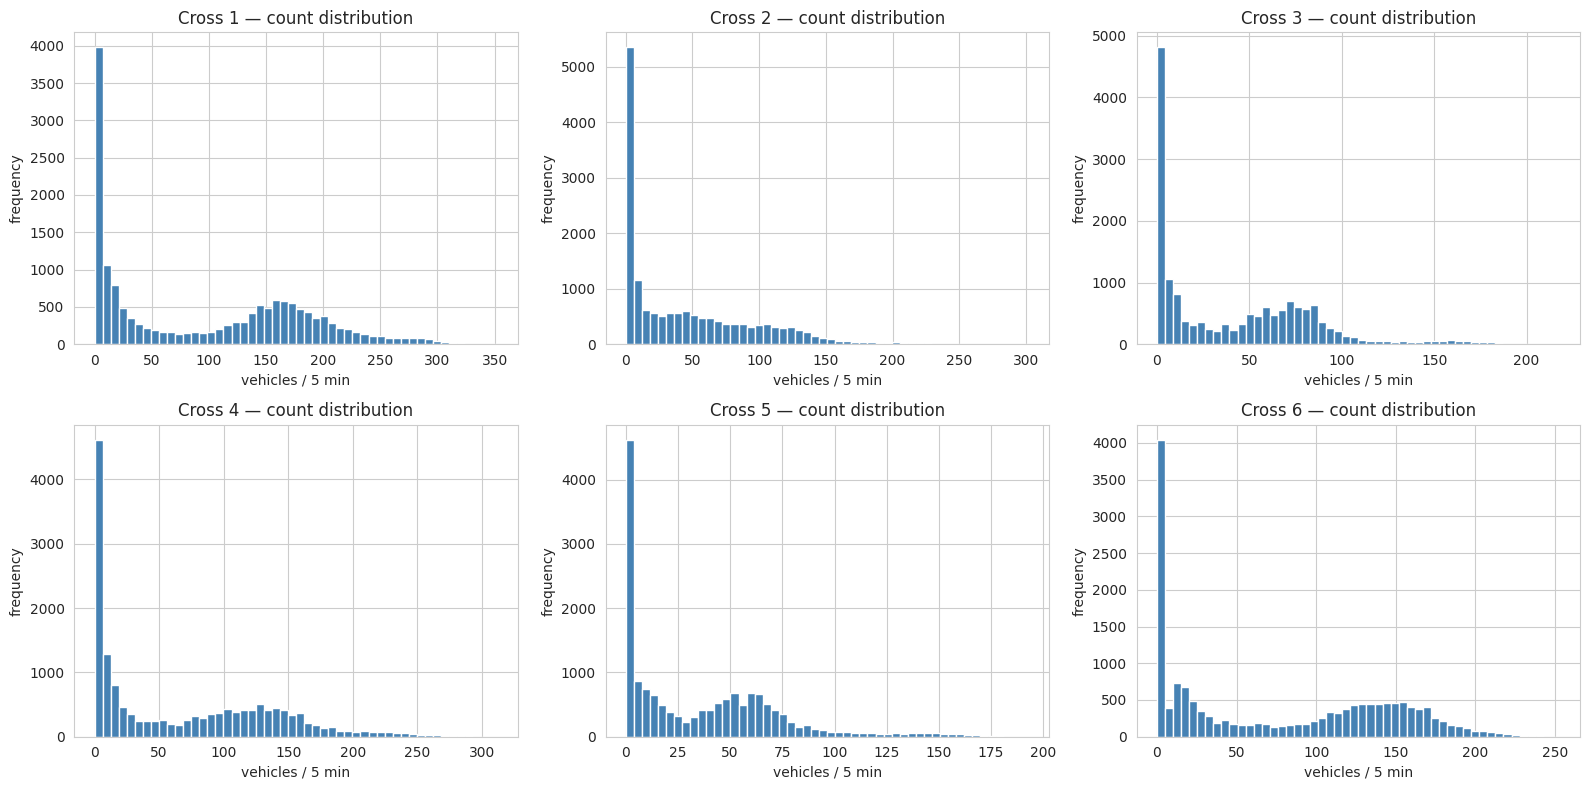

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), df.columns):
    ax.hist(df[col], bins=50, color="steelblue", edgecolor="white")
    ax.set_title(f"{col} — count distribution")
    ax.set_xlabel("vehicles / 5 min"); ax.set_ylabel("frequency")
plt.tight_layout(); plt.show()

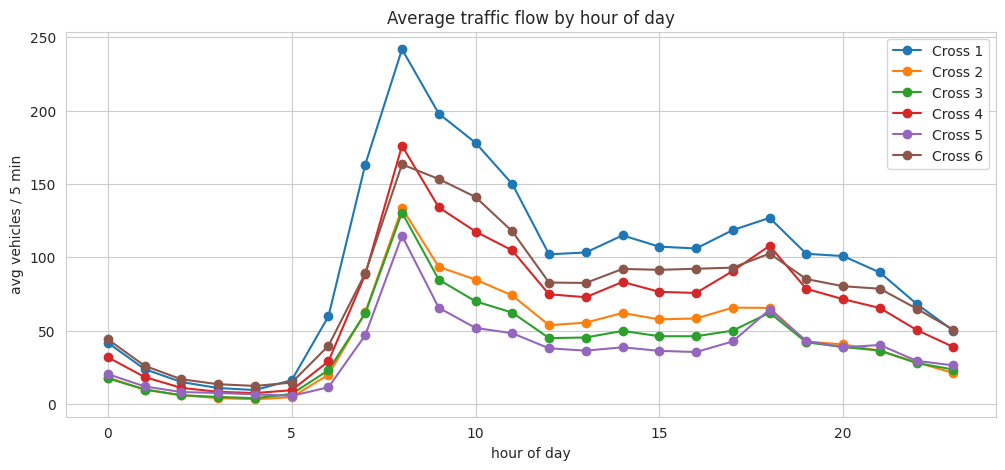

In [ ]:
tmp = df.copy()
tmp["hour"] = ((tmp.index % 288) * 5) // 60
hourly = tmp.groupby("hour")[list(df.columns)].mean()
plt.figure(figsize=(12, 5))
for col in df.columns:
    plt.plot(hourly.index, hourly[col], marker="o", label=col)
plt.title("Average traffic flow by hour of day")
plt.xlabel("hour of day"); plt.ylabel("avg vehicles / 5 min")
plt.legend(); plt.show()

In [ ]:
# 4 of the 6 crosses represent the 4 lanes of one intersection (paper's setup).
LANES = ["Cross 1", "Cross 2", "Cross 3", "Cross 4"]
data = df[LANES].astype(float).copy()
print("Working data shape:", data.shape)
print("Zeros before cleaning:", int((data == 0).sum().sum()))

Working data shape: (16128, 4)
Zeros before cleaning: 15100


In [ ]:
def fix_zeros_moving_avg(series, window=12):
    vals = series.values.astype(float)
    for i in range(len(vals)):
        if vals[i] == 0:
            prev = vals[max(0, i - window):i]; prev = prev[prev > 0]
            if len(prev) > 0:
                vals[i] = prev.mean()
    return pd.Series(vals, index=series.index)

for c in LANES:
    data[c] = fix_zeros_moving_avg(data[c])
print("Zeros after cleaning:", int((data == 0).sum().sum()))

Zeros after cleaning: 0


In [ ]:
split_idx = int(len(data) * 0.75)
train_raw = data.iloc[:split_idx]
test_raw  = data.iloc[split_idx:]
print(f"Train rows: {len(train_raw)} | Test rows: {len(test_raw)}")

Train rows: 12096 | Test rows: 4032


In [ ]:
scaler = MinMaxScaler()
train_scaled = scaler.fit_transform(train_raw)
test_scaled  = scaler.transform(test_raw)
print("Train scaled range:", round(train_scaled.min(), 3), "to", round(train_scaled.max(), 3))

Train scaled range: 0.0 to 1.0


In [ ]:
# 12 readings (1 hour) x 4 lanes = 48 inputs  ->  next reading x 4 lanes = 4 outputs.
WINDOW = 12
def make_windows(arr, window=WINDOW):
    X, Y = [], []
    for i in range(len(arr) - window):
        X.append(arr[i:i + window].flatten())   # 48 features
        Y.append(arr[i + window])                # 4 targets
    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

X_train, Y_train = make_windows(train_scaled)
X_test,  Y_test  = make_windows(test_scaled)
print("X_train:", X_train.shape, "| Y_train:", Y_train.shape)
print("X_test :", X_test.shape,  "| Y_test :", Y_test.shape)

X_train: (12084, 48) | Y_train: (12084, 4)
X_test : (4020, 48) | Y_test : (4020, 4)


In [ ]:
def evaluate(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(y_true_scaled).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    mask = y_true > 1e-6
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "R2":   r2_score(y_true, y_pred),
        "EV":   explained_variance_score(y_true, y_pred),
    }

In [ ]:
t0 = time.time()
lin = LinearRegression().fit(X_train, Y_train)
lin_time = time.time() - t0
lin_results = evaluate(Y_test, lin.predict(X_test), scaler)
print("Linear Regression:", {k: round(v, 4) for k, v in lin_results.items()})
print(f"Training time: {lin_time:.4f} s")

Linear Regression: {'MAE': 10.7132, 'MAPE': np.float32(22.7959), 'RMSE': np.float64(15.5883), 'R2': 0.946, 'EV': 0.946}
Training time: 0.1461 s


In [ ]:
# Input layer  : 48 neurons (12 readings x 4 lanes), fed in all at once
# Hidden layer1: 128 neurons + ReLU
# Hidden layer2: 64  neurons + ReLU   (>=2 hidden layers satisfied)
# Output layer : 4 neurons (next reading for 4 lanes), LINEAR (regression)
class TrafficMLP(nn.Module):
    def __init__(self, in_dim=48, out_dim=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, out_dim),
        )
    def forward(self, x):
        return self.net(x)

# show architecture + parameter count
_demo = TrafficMLP(X_train.shape[1], Y_train.shape[1])
print(_demo)
print("Total parameters:", sum(p.numel() for p in _demo.parameters()))

TrafficMLP(
  (net): Sequential(
    (0): Linear(in_features=48, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)
Total parameters: 14788


In [ ]:
# Validation = last 10% of train (chronological, no shuffle)
val_cut = int(len(X_train) * 0.9)
X_tr, Y_tr   = X_train[:val_cut], Y_train[:val_cut]
X_val, Y_val = X_train[val_cut:], Y_train[val_cut:]

to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=device)
X_tr_t, Y_tr_t   = to_t(X_tr),  to_t(Y_tr)
X_val_t, Y_val_t = to_t(X_val), to_t(Y_val)
X_test_t         = to_t(X_test)

def train_mlp(batch_size, lr=0.01, epochs=20, label=""):
    """Train the MLP by gradient descent.  optimizer.step() applies
       the formula  w <- w - lr * gradient.  batch_size controls the variant:
       1 = stochastic (SGD), 128 = mini-batch, len = full-batch."""
    torch.manual_seed(RANDOM_STATE)
    model = TrafficMLP(X_train.shape[1], Y_train.shape[1]).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)   # plain GD

    n = len(X_tr_t)
    bs = n if batch_size >= n else batch_size
    updates_per_epoch = (n + bs - 1) // bs          # how many weight updates/epoch
    train_losses, val_losses = [], []

    print(f"\n=== Training [{label}] | batch={bs}, lr={lr}, epochs={epochs} "
          f"| {updates_per_epoch} weight-updates per epoch ===")
    t0 = time.time()
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        running = 0.0
        for i in range(0, n, bs):
            idx = perm[i:i + bs]
            xb, yb = X_tr_t[idx], Y_tr_t[idx]
            optimizer.zero_grad()              # clear old gradients
            loss = criterion(model(xb), yb)    # forward + loss
            loss.backward()                    # gradient (backprop)
            optimizer.step()                   # w <- w - lr*gradient
            running += loss.item() * len(idx)
        train_loss = running / n

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), Y_val_t).item()
        train_losses.append(train_loss)
        val_losses.append(val_loss)

        # ---- print EVERY epoch ----
        print(f"  epoch {epoch+1:2d}/{epochs}   train_loss {train_loss:.6f}   val_loss {val_loss:.6f}")

    train_time = time.time() - t0
    model.eval()
    with torch.no_grad():
        pred = model(X_test_t).cpu().numpy()
    results = evaluate(Y_test, pred, scaler)
    print(f"  --> finished in {train_time:.2f}s | test R2={results['R2']:.4f}")
    return model, results, train_time, train_losses, val_losses, pred

In [ ]:
# Mini-batch: one weight update per 128 examples.
(mlp_mb, mb_results, mb_time,
 mb_train_losses, mb_val_losses, mb_pred) = train_mlp(batch_size=128, lr=0.01,
                                                      epochs=20, label="MLP mini-batch")


=== Training [MLP mini-batch] | batch=128, lr=0.01, epochs=20 | 85 weight-updates per epoch ===
  epoch  1/20   train_loss 0.063376   val_loss 0.034332
  epoch  2/20   train_loss 0.025390   val_loss 0.019627
  epoch  3/20   train_loss 0.018021   val_loss 0.016470
  epoch  4/20   train_loss 0.016216   val_loss 0.015170
  epoch  5/20   train_loss 0.015237   val_loss 0.014154
  epoch  6/20   train_loss 0.014403   val_loss 0.013249
  epoch  7/20   train_loss 0.013642   val_loss 0.012414
  epoch  8/20   train_loss 0.012956   val_loss 0.011657
  epoch  9/20   train_loss 0.012338   val_loss 0.010971
  epoch 10/20   train_loss 0.011778   val_loss 0.010355
  epoch 11/20   train_loss 0.011272   val_loss 0.009808
  epoch 12/20   train_loss 0.010815   val_loss 0.009313
  epoch 13/20   train_loss 0.010401   val_loss 0.008856
  epoch 14/20   train_loss 0.010025   val_loss 0.008454
  epoch 15/20   train_loss 0.009685   val_loss 0.008093
  epoch 16/20   train_loss 0.009377   val_loss 0.007771
  epoch

In [ ]:
# True SGD: one weight update PER example (~12k updates/epoch).
# NOTE: this is slow (~2-3 min) because of the huge number of updates.
(mlp_sgd, sgd_results, sgd_time,
 sgd_train_losses, sgd_val_losses, sgd_pred) = train_mlp(batch_size=1, lr=0.01,
                                                        epochs=20, label="MLP SGD")


=== Training [MLP SGD] | batch=1, lr=0.01, epochs=20 | 10875 weight-updates per epoch ===
  epoch  1/20   train_loss 0.006477   val_loss 0.003176
  epoch  2/20   train_loss 0.002581   val_loss 0.002758
  epoch  3/20   train_loss 0.002127   val_loss 0.002467
  epoch  4/20   train_loss 0.001980   val_loss 0.002486
  epoch  5/20   train_loss 0.001904   val_loss 0.002326
  epoch  6/20   train_loss 0.001852   val_loss 0.002309
  epoch  7/20   train_loss 0.001818   val_loss 0.002253
  epoch  8/20   train_loss 0.001789   val_loss 0.002267
  epoch  9/20   train_loss 0.001767   val_loss 0.002245
  epoch 10/20   train_loss 0.001743   val_loss 0.002200
  epoch 11/20   train_loss 0.001726   val_loss 0.002243
  epoch 12/20   train_loss 0.001712   val_loss 0.002202
  epoch 13/20   train_loss 0.001698   val_loss 0.002194
  epoch 14/20   train_loss 0.001685   val_loss 0.002154
  epoch 15/20   train_loss 0.001671   val_loss 0.002151
  epoch 16/20   train_loss 0.001661   val_loss 0.002206
  epoch 17/20

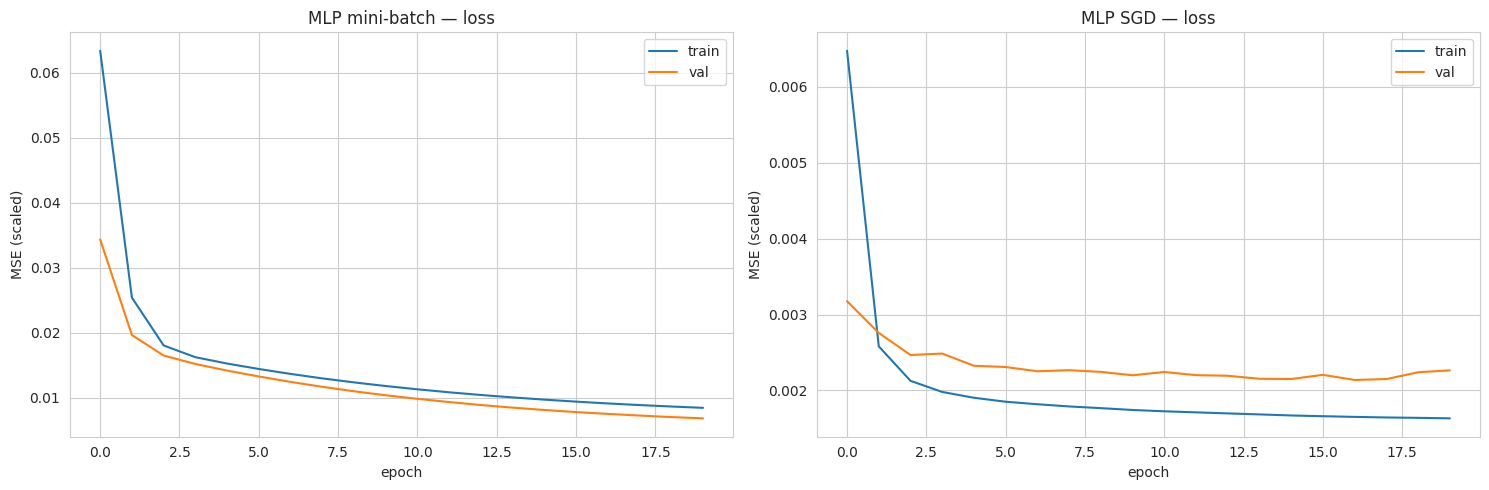

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(mb_train_losses, label="train"); axes[0].plot(mb_val_losses, label="val")
axes[0].set_title("MLP mini-batch — loss"); axes[0].set_xlabel("epoch")
axes[0].set_ylabel("MSE (scaled)"); axes[0].legend(); axes[0].grid(True)

axes[1].plot(sgd_train_losses, label="train"); axes[1].plot(sgd_val_losses, label="val")
axes[1].set_title("MLP SGD — loss"); axes[1].set_xlabel("epoch")
axes[1].set_ylabel("MSE (scaled)"); axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()

In [ ]:
results = {
    "Linear Regression":  {**lin_results, "Time(s)": lin_time},
    "MLP (mini-batch)":   {**mb_results,  "Time(s)": mb_time},
    "MLP (SGD)":          {**sgd_results, "Time(s)": sgd_time},
}
results_df = pd.DataFrame(results).T[["MAE", "MAPE", "RMSE", "R2", "EV", "Time(s)"]].round(4)
print("=== PERFORMANCE + RUNTIME COMPARISON ===")
display(results_df)
# Paper reference (MLP): MAE 10.83, RMSE 15.42, R2 0.930, MAPE 21%

=== PERFORMANCE + RUNTIME COMPARISON ===


,MAE,MAPE,RMSE,R2,EV,Time(s)
Linear Regression,10.7132,22.7959,15.5883,0.9460,0.9460,0.1461
MLP (mini-batch),21.5371,65.8032,29.7840,0.8030,0.8033,1.8253
MLP (SGD),11.2139,24.3565,16.1710,0.9419,0.9440,159.2966


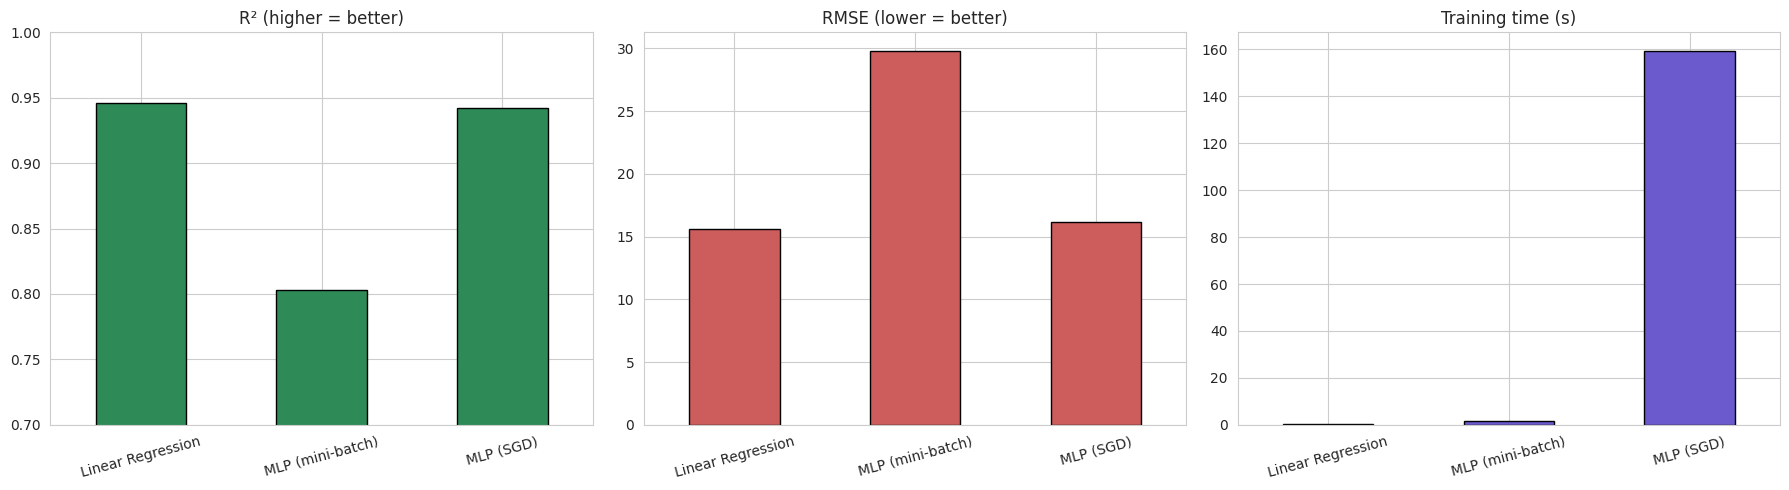

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
results_df["R2"].plot(kind="bar", ax=axes[0], color="seagreen", edgecolor="black")
axes[0].set_title("R² (higher = better)"); axes[0].set_ylim(0.7, 1.0); axes[0].tick_params(axis="x", rotation=15)
results_df["RMSE"].plot(kind="bar", ax=axes[1], color="indianred", edgecolor="black")
axes[1].set_title("RMSE (lower = better)"); axes[1].tick_params(axis="x", rotation=15)
results_df["Time(s)"].plot(kind="bar", ax=axes[2], color="slateblue", edgecolor="black")
axes[2].set_title("Training time (s)"); axes[2].tick_params(axis="x", rotation=15)
plt.tight_layout(); plt.show()

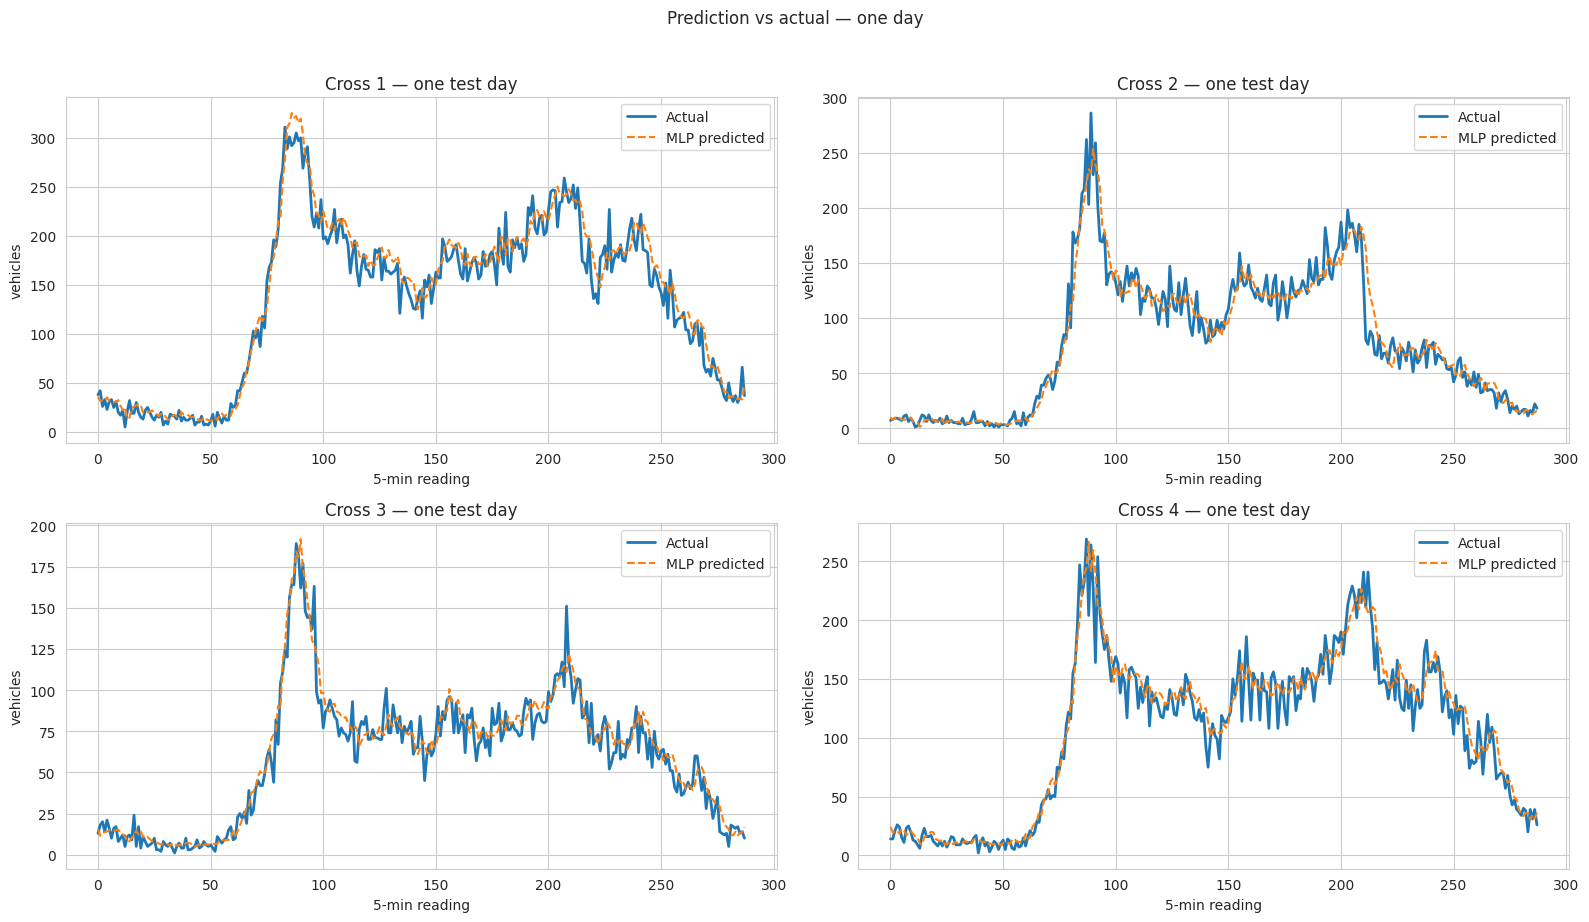

In [ ]:
# Use the best MLP (SGD) for the prediction plots.
best_pred = scaler.inverse_transform(sgd_pred)
y_test_real = scaler.inverse_transform(Y_test)

ONE_DAY = 288
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for idx, (ax, lane) in enumerate(zip(axes.ravel(), LANES)):
    ax.plot(y_test_real[:ONE_DAY, idx], label="Actual", linewidth=2)
    ax.plot(best_pred[:ONE_DAY, idx], label="MLP predicted", linestyle="--")
    ax.set_title(f"{lane} — one test day"); ax.set_xlabel("5-min reading")
    ax.set_ylabel("vehicles"); ax.legend()
plt.suptitle("Prediction vs actual — one day", y=1.02)
plt.tight_layout(); plt.show()

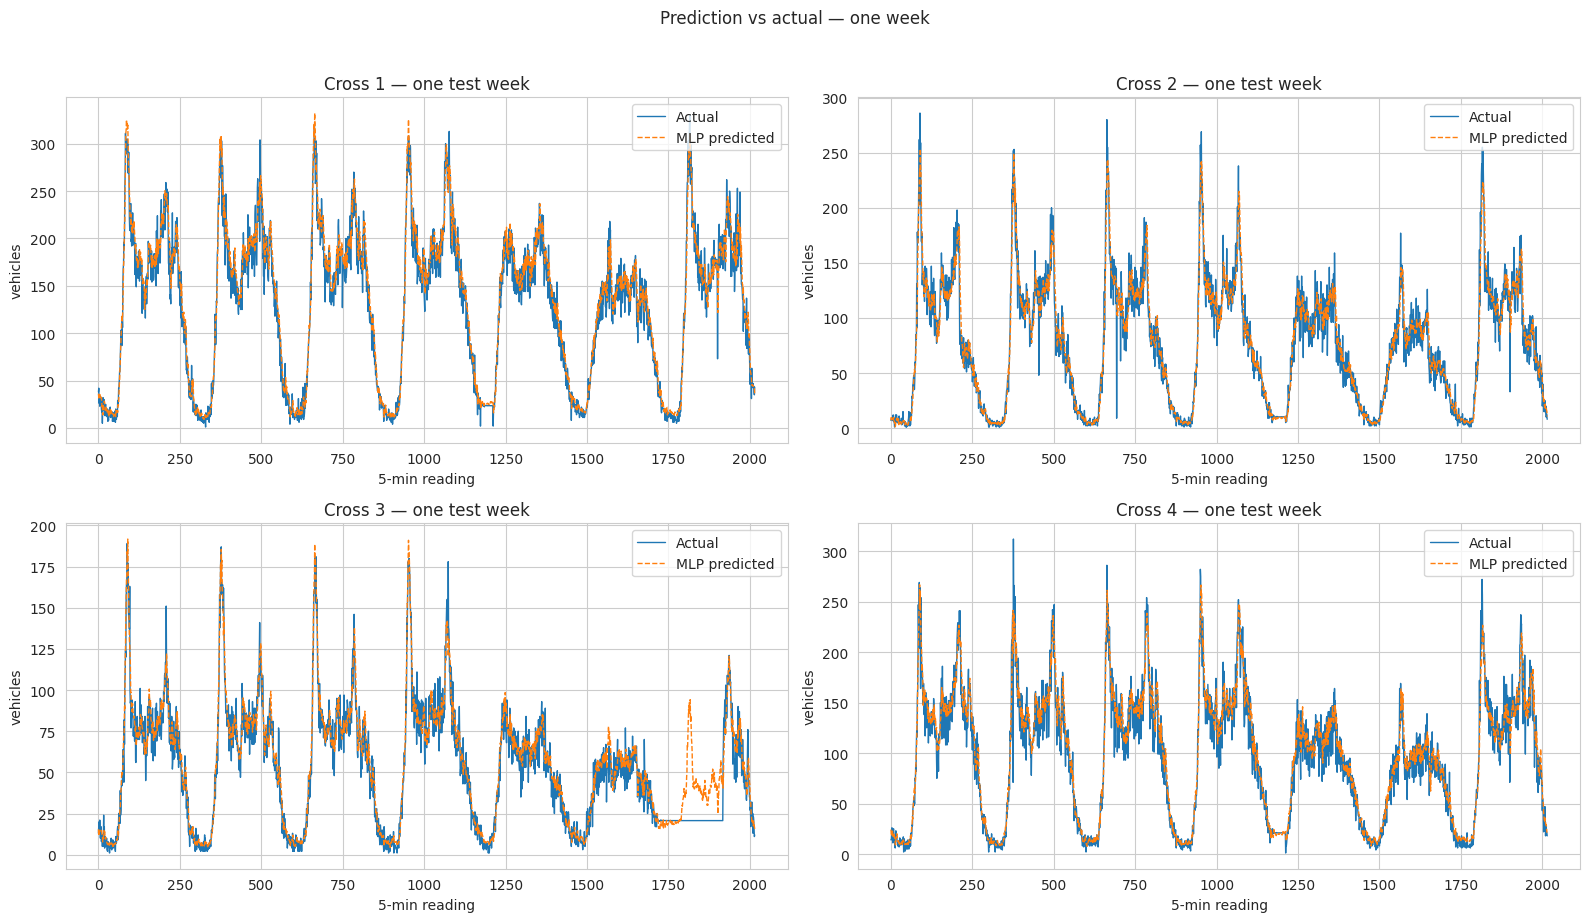

In [ ]:
ONE_WEEK = 288 * 7
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
for idx, (ax, lane) in enumerate(zip(axes.ravel(), LANES)):
    ax.plot(y_test_real[:ONE_WEEK, idx], label="Actual", linewidth=1)
    ax.plot(best_pred[:ONE_WEEK, idx], label="MLP predicted", linestyle="--", linewidth=1)
    ax.set_title(f"{lane} — one test week"); ax.set_xlabel("5-min reading")
    ax.set_ylabel("vehicles"); ax.legend()
plt.suptitle("Prediction vs actual — one week", y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
print(df.shape)        # e.g. (16128, 6)
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

(16128, 6)
Rows: 16128
Columns: 6


In [ ]:
# ============================================================
# Traffic Volume Prediction with MLP — Metro Interstate dataset
# Preprocessing & experimental design adapted from Das (2023)
# and MSTIM (2025). Single MLP model (4 hidden layers).
# Setup: Adam, lr=0.001, batch=64, 50 epochs + early stopping.
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, explained_variance_score)
import torch
import torch.nn as nn

RANDOM_STATE = 0
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
sns.set_style("whitegrid")
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Libraries loaded. Device:", device)

Libraries loaded. Device: cpu


In [ ]:
# Option A: upload the CSV
from google.colab import files
uploaded = files.upload()
FILENAME = list(uploaded.keys())[0]
df = pd.read_csv(FILENAME)

# Option B (if upload is fiddly): fetch from UCI instead — comment out Option A
#   !pip install ucimlrepo -q
#   from ucimlrepo import fetch_ucirepo
#   data = fetch_ucirepo(id=492)
#   df = pd.concat([data.data.features, data.data.targets], axis=1)

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Saving Metro_Interstate_Traffic_Volume.csv to Metro_Interstate_Traffic_Volume.csv
Shape: (48204, 9)
Columns: ['holiday', 'temp', 'rain_1h', 'snow_1h', 'clouds_all', 'weather_main', 'weather_description', 'date_time', 'traffic_volume']


,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
0,NaN,288.28,0.0,0.0,40,Clouds,scattered clouds,2012-10-02 09:00:00,5545
1,NaN,289.36,0.0,0.0,75,Clouds,broken clouds,2012-10-02 10:00:00,4516
2,NaN,289.58,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 11:00:00,4767
3,NaN,290.13,0.0,0.0,90,Clouds,overcast clouds,2012-10-02 12:00:00,5026
4,NaN,291.14,0.0,0.0,75,Clouds,broken clouds,2012-10-02 13:00:00,4918


In [ ]:
print("=== DATA TYPES ==="); print(df.dtypes, "\n")
print("=== MISSING VALUES ==="); print(df.isna().sum(), "\n")
print("=== DUPLICATE ROWS:", df.duplicated().sum(), "\n")
print("=== TARGET (traffic_volume) STATS ===")
print(df['traffic_volume'].describe().round(1))
print("\nweather_main categories:", df['weather_main'].nunique())
print("holiday non-null entries:", df['holiday'].notna().sum(), "(rest are normal days)")

=== DATA TYPES ===
holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object 

=== MISSING VALUES ===
holiday                48143
temp                       0
rain_1h                    0
snow_1h                    0
clouds_all                 0
weather_main               0
weather_description        0
date_time                  0
traffic_volume             0
dtype: int64 

=== DUPLICATE ROWS: 17 

=== TARGET (traffic_volume) STATS ===
count    48204.0
mean      3259.8
std       1986.9
min          0.0
25%       1193.0
50%       3380.0
75%       4933.0
max       7280.0
Name: traffic_volume, dtype: float64

weather_main categories: 11
holiday non-null entries: 61 (rest are normal days)


temp min (0 = impossible 0-Kelvin error): 0.0
rain_1h max (9831 = sensor error): 9831.3


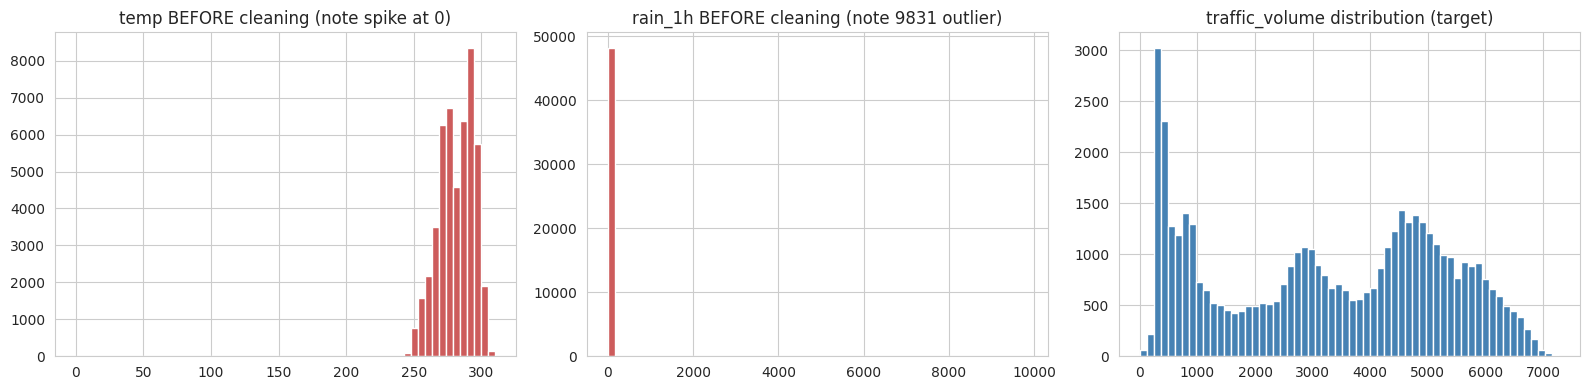

In [ ]:
# Known data-quality issues in this dataset:
print("temp min (0 = impossible 0-Kelvin error):", df['temp'].min())
print("rain_1h max (9831 = sensor error):", df['rain_1h'].max())

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df['temp'], bins=60, color="indianred", edgecolor="white")
axes[0].set_title("temp BEFORE cleaning (note spike at 0)")
axes[1].hist(df['rain_1h'], bins=60, color="indianred", edgecolor="white")
axes[1].set_title("rain_1h BEFORE cleaning (note 9831 outlier)")
axes[2].hist(df['traffic_volume'], bins=60, color="steelblue", edgecolor="white")
axes[2].set_title("traffic_volume distribution (target)")
plt.tight_layout(); plt.show()

In [ ]:
df['date_time'] = pd.to_datetime(df['date_time'])
df = df.drop_duplicates(subset='date_time').sort_values('date_time').reset_index(drop=True)

# Remove physically impossible values
before = len(df)
df = df[df['temp'] > 0]            # drop 0-Kelvin errors
df = df[df['rain_1h'] < 1000]      # drop the absurd 9831 mm/h reading
print(f"Removed {before - len(df)} impossible-value rows. Remaining: {len(df)}")

Removed 11 impossible-value rows. Remaining: 40564


In [ ]:
# holiday column only labels the FIRST hour of a holiday -> turn into a binary flag
df['is_holiday'] = df['holiday'].notna().astype(int)

# extract time features from the timestamp
df['hour']  = df['date_time'].dt.hour
df['dow']   = df['date_time'].dt.dayofweek      # 0=Mon ... 6=Sun
df['month'] = df['date_time'].dt.month
print("Added is_holiday, hour, dow, month.")
df[['date_time', 'is_holiday', 'hour', 'dow', 'month', 'traffic_volume']].head()

Added is_holiday, hour, dow, month.


,date_time,is_holiday,hour,dow,month,traffic_volume
0,2012-10-02 09:00:00,0,9,1,10,5545
1,2012-10-02 10:00:00,0,10,1,10,4516
2,2012-10-02 11:00:00,0,11,1,10,4767
3,2012-10-02 12:00:00,0,12,1,10,5026
4,2012-10-02 13:00:00,0,13,1,10,4918


Rows after IQR outlier removal: 38511


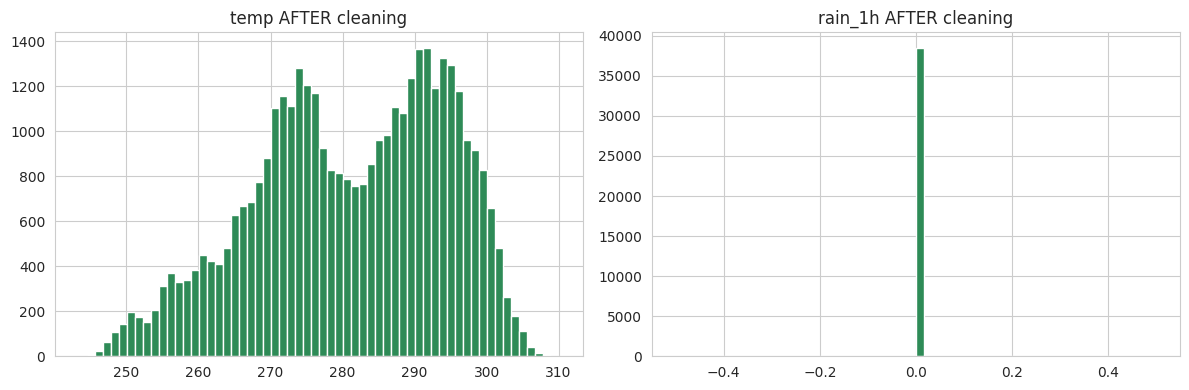

In [ ]:
# Das removes outliers on temp and rain using the interquartile range:
# anything 1.5*IQR below Q1 or above Q3 is dropped.
for col in ['temp', 'rain_1h']:
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    df = df[(df[col] >= lo) & (df[col] <= hi)]
df = df.reset_index(drop=True)
print("Rows after IQR outlier removal:", len(df))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['temp'], bins=60, color="seagreen", edgecolor="white")
axes[0].set_title("temp AFTER cleaning")
axes[1].hist(df['rain_1h'], bins=60, color="seagreen", edgecolor="white")
axes[1].set_title("rain_1h AFTER cleaning")
plt.tight_layout(); plt.show()

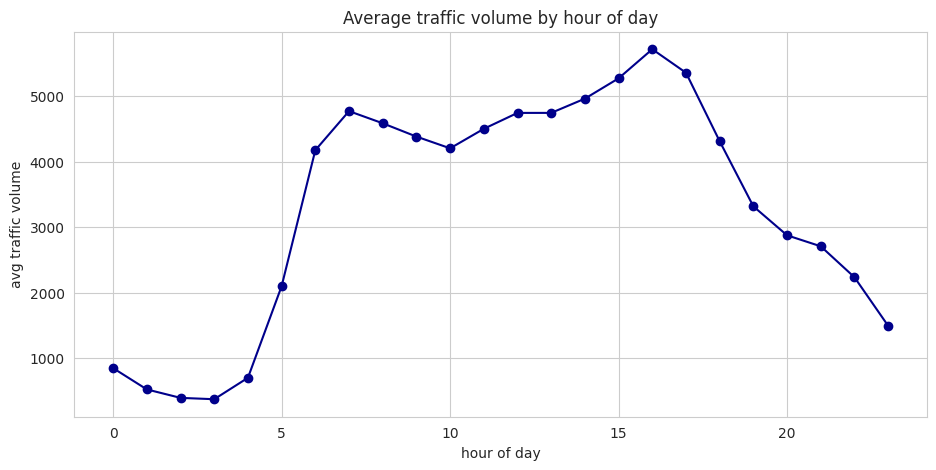

In [ ]:
hourly = df.groupby('hour')['traffic_volume'].mean()
plt.figure(figsize=(11, 5))
plt.plot(hourly.index, hourly.values, marker="o", color="darkblue")
plt.title("Average traffic volume by hour of day")
plt.xlabel("hour of day"); plt.ylabel("avg traffic volume")
plt.grid(True); plt.show()

In [ ]:
# One-hot encode weather_main (~11 categories). weather_description (38 cats)
# is dropped to keep the input manageable (mention this in the report).
weather = pd.get_dummies(df['weather_main'], prefix='wm').astype(float)
numeric = df[['temp', 'rain_1h', 'snow_1h', 'clouds_all',
              'is_holiday', 'hour', 'dow', 'month']].astype(float)
features = pd.concat([numeric, weather], axis=1)
target   = df['traffic_volume'].astype(float).values.reshape(-1, 1)

print("Feature matrix shape:", features.shape)
print("Features:", list(features.columns))

Feature matrix shape: (38511, 19)
Features: ['temp', 'rain_1h', 'snow_1h', 'clouds_all', 'is_holiday', 'hour', 'dow', 'month', 'wm_Clear', 'wm_Clouds', 'wm_Drizzle', 'wm_Fog', 'wm_Haze', 'wm_Mist', 'wm_Rain', 'wm_Smoke', 'wm_Snow', 'wm_Squall', 'wm_Thunderstorm']


In [ ]:
# Chronological 80/20 split point for fitting the scaler (no leakage).
split_point = int(len(features) * 0.8)
feat_scaler = MinMaxScaler().fit(features.iloc[:split_point])
targ_scaler = MinMaxScaler().fit(target[:split_point])

X_scaled = feat_scaler.transform(features)
y_scaled = targ_scaler.transform(target)
print("Scaled. Feature range:", round(X_scaled.min(), 2), "to", round(X_scaled.max(), 2))

Scaled. Feature range: 0.0 to 1.03


In [ ]:
# Use the past WINDOW hours of features to predict the next hour's volume.
WINDOW = 24                      # try 6, 12, 24 (Das's experiment)
def make_windows(X, y, window=WINDOW):
    Xw, Yw = [], []
    for i in range(len(X) - window):
        Xw.append(X[i:i + window].flatten())   # window * num_features
        Yw.append(y[i + window])               # next-hour volume (1 value)
    return np.array(Xw, dtype=np.float32), np.array(Yw, dtype=np.float32)

X_all, Y_all = make_windows(X_scaled, y_scaled)
print("X_all:", X_all.shape, "| Y_all:", Y_all.shape)
print("Input dimension (window * features):", X_all.shape[1])

X_all: (38487, 456) | Y_all: (38487, 1)
Input dimension (window * features): 456


In [ ]:
split2 = int(len(X_all) * 0.8)
X_train, Y_train = X_all[:split2], Y_all[:split2]
X_test,  Y_test  = X_all[split2:], Y_all[split2:]

val_cut = int(len(X_train) * 0.9)
X_tr, Y_tr   = X_train[:val_cut], Y_train[:val_cut]
X_val, Y_val = X_train[val_cut:], Y_train[val_cut:]

to_t = lambda a: torch.tensor(a, dtype=torch.float32, device=device)
X_tr_t, Y_tr_t   = to_t(X_tr),  to_t(Y_tr)
X_val_t, Y_val_t = to_t(X_val), to_t(Y_val)
X_test_t         = to_t(X_test)
print(f"train: {len(X_tr)} | val: {len(X_val)} | test: {len(X_test)}")

train: 27710 | val: 3079 | test: 7698


In [ ]:
def evaluate(y_true_scaled, y_pred_scaled, scaler):
    y_true = scaler.inverse_transform(y_true_scaled).flatten()
    y_pred = scaler.inverse_transform(y_pred_scaled).flatten()
    mask = y_true > 1e-6
    return {
        "MAE":  mean_absolute_error(y_true, y_pred),
        "MAPE": np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100,
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MSE":  mean_squared_error(y_true, y_pred),
        "R2":   r2_score(y_true, y_pred),
        "EV":   explained_variance_score(y_true, y_pred),
    }

In [ ]:
# Architecture matches Das's hidden-layer sizes (128, 64, 32, 16), adapted to a
# feed-forward MLP. ReLU activations; single linear output (next-hour volume).
class TrafficMLP(nn.Module):
    def __init__(self, in_dim, out_dim=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),     nn.ReLU(),
            nn.Linear(64, 32),      nn.ReLU(),
            nn.Linear(32, 16),      nn.ReLU(),
            nn.Linear(16, out_dim),
        )
    def forward(self, x):
        return self.net(x)

model = TrafficMLP(X_all.shape[1]).to(device)
print(model)
print("Total parameters:", sum(p.numel() for p in model.parameters()))

TrafficMLP(
  (net): Sequential(
    (0): Linear(in_features=456, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=16, bias=True)
    (7): ReLU()
    (8): Linear(in_features=16, out_features=1, bias=True)
  )
)
Total parameters: 69377


In [ ]:
EPOCHS     = 20
BATCH_SIZE = 64
LR         = 0.001

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)   # Adam optimizer

In [ ]:
train_losses, val_losses = [], []
n = len(X_tr_t)

print(f"Training MLP | batch={BATCH_SIZE}, lr={LR}, epochs={EPOCHS} (no early stopping)\n")
t0 = time.time()
for epoch in range(EPOCHS):
    model.train()
    perm = torch.randperm(n)
    running = 0.0
    for i in range(0, n, BATCH_SIZE):
        idx = perm[i:i + BATCH_SIZE]
        xb, yb = X_tr_t[idx], Y_tr_t[idx]
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * len(idx)
    train_loss = running / n

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t), Y_val_t).item()
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    print(f"epoch {epoch+1:2d}/{EPOCHS}  train {train_loss:.6f}  val {val_loss:.6f}")

train_time = time.time() - t0
print(f"\nTraining time: {train_time:.2f} s | final val loss: {val_losses[-1]:.6f}")

Training MLP | batch=64, lr=0.001, epochs=20 (no early stopping)

epoch  1/20  train 0.013586  val 0.009240
epoch  2/20  train 0.012672  val 0.009288
epoch  3/20  train 0.011866  val 0.007348
epoch  4/20  train 0.011044  val 0.007886
epoch  5/20  train 0.010297  val 0.007027
epoch  6/20  train 0.009559  val 0.007995
epoch  7/20  train 0.009177  val 0.007393
epoch  8/20  train 0.008770  val 0.009233
epoch  9/20  train 0.008296  val 0.006557
epoch 10/20  train 0.008023  val 0.006608
epoch 11/20  train 0.007513  val 0.006594
epoch 12/20  train 0.007201  val 0.011587
epoch 13/20  train 0.006866  val 0.007648
epoch 14/20  train 0.006745  val 0.009151
epoch 15/20  train 0.006780  val 0.008461
epoch 16/20  train 0.006121  val 0.006943
epoch 17/20  train 0.005978  val 0.006790
epoch 18/20  train 0.005915  val 0.009384
epoch 19/20  train 0.005684  val 0.008684
epoch 20/20  train 0.005559  val 0.007615

Training time: 28.07 s | final val loss: 0.007615


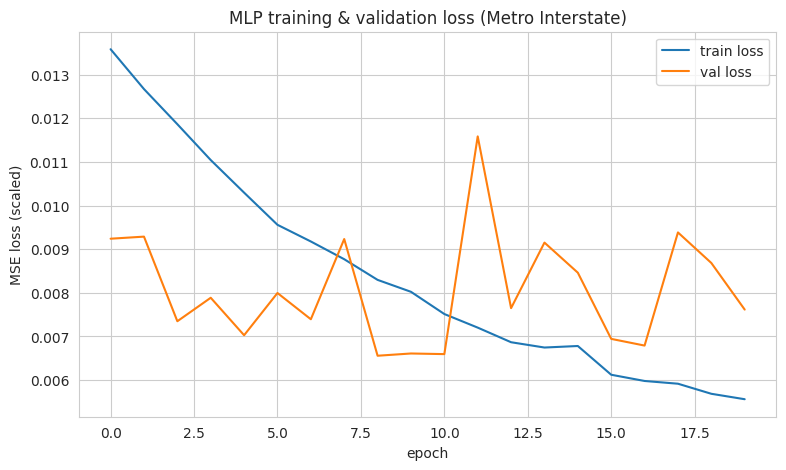

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(train_losses, label="train loss")
plt.plot(val_losses,   label="val loss")
plt.title("MLP training & validation loss (Metro Interstate)")
plt.xlabel("epoch"); plt.ylabel("MSE loss (scaled)")
plt.legend(); plt.grid(True); plt.show()

In [ ]:
model.eval()
with torch.no_grad():
    pred_scaled = model(X_test_t).cpu().numpy()
results = evaluate(Y_test, pred_scaled, targ_scaler)
print("=== MLP TEST METRICS (real traffic-volume units) ===")
for k, v in results.items():
    print(f"{k:>5}: {v:.4f}")

=== MLP TEST METRICS (real traffic-volume units) ===
  MAE: 425.2327
 MAPE: 21.8923
 RMSE: 634.0324
  MSE: 401997.0625
   R2: 0.8965
   EV: 0.8966


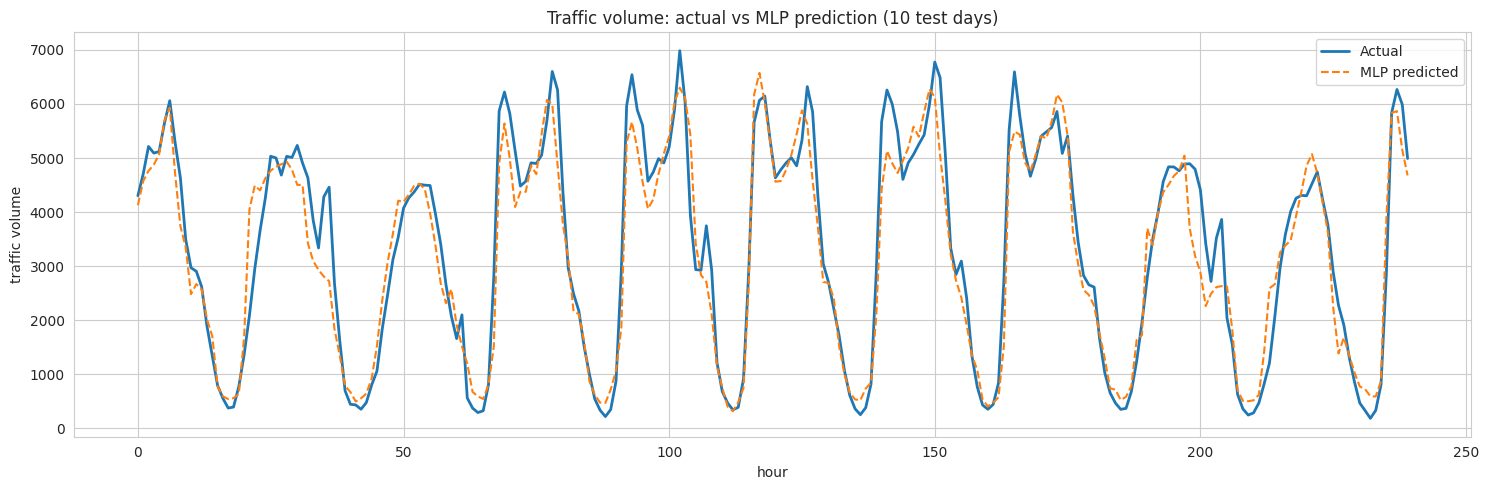

In [ ]:
y_test_real = targ_scaler.inverse_transform(Y_test).flatten()
pred_real   = targ_scaler.inverse_transform(pred_scaled).flatten()

WIN_VIEW = 24 * 10   # show 10 days of hourly predictions
plt.figure(figsize=(15, 5))
plt.plot(y_test_real[:WIN_VIEW], label="Actual", linewidth=2)
plt.plot(pred_real[:WIN_VIEW], label="MLP predicted", linestyle="--")
plt.title("Traffic volume: actual vs MLP prediction (10 test days)")
plt.xlabel("hour"); plt.ylabel("traffic volume"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

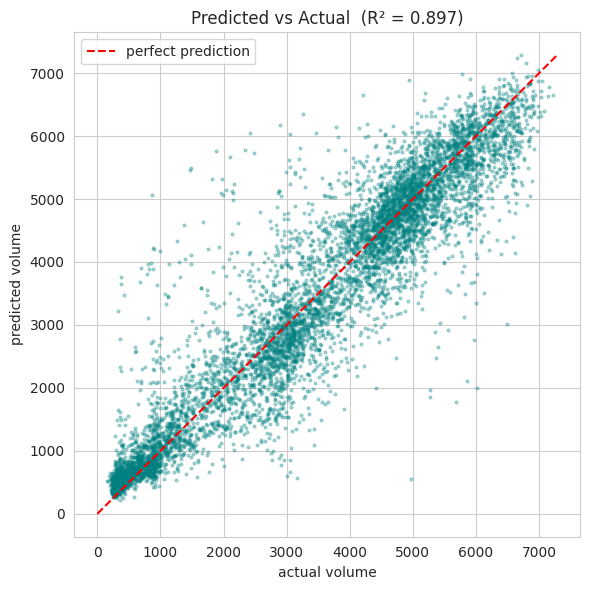

In [ ]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test_real, pred_real, s=4, alpha=0.3, color="teal")
lims = [0, max(y_test_real.max(), pred_real.max())]
plt.plot(lims, lims, 'r--', label="perfect prediction")
plt.title(f"Predicted vs Actual  (R² = {results['R2']:.3f})")
plt.xlabel("actual volume"); plt.ylabel("predicted volume")
plt.legend(); plt.tight_layout(); plt.show()